# Density-Aware Uncertainty for Protein Stability Prediction

## Architecture

### Part 1 — Minimal Version (density-based epistemic)

```
Input (A3, 680-d)
    |
    v
[Trunk MLP]  680 -> 64 -> 32 (hidden h)
    |
    +---> mu head: linear(32 -> 1)
    |
    +---> sigma_alea head: MLP([h || f_bio] -> 1)
    |         f_bio = [RSA, BLOSUM, hidden_norm, local_density]
    |
    +---> sigma_epi: c * kNN_dist(h(x), H_train)
```

### Part 2 — Recommended Model (Laplace last-layer)

$$\mu(x) = w^\top h(x), \quad w \sim \text{Laplace posterior}$$

$$\sigma^2_{\text{epi}}(x) = \sigma^2_{\text{Laplace}}(x) + \lambda \cdot \text{kNN\_dist}(h(x), H_{\text{train}})$$

$$y | x \sim \text{Student-t}\!\left(\mu(x),\; \sqrt{\sigma^2_{\text{alea}} + \sigma^2_{\text{epi}}},\; \nu\right)$$

In [1]:
import sys, warnings, logging, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from scipy.spatial import cKDTree
from scipy import stats as sp_stats

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

sys.path.insert(0, ".")
from uapp.data import load_cached_embeddings, make_loader
from uapp.evaluate import (
    compute_coverage_curve, compute_ice, compute_rmse,
    compute_mae, compute_gaussian_nll,
)
from uapp.losses import student_t_nll_loss

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")
log = logging.getLogger("density_uq")

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "legend.fontsize": 8, "figure.facecolor": "white",
})

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CACHE_DIR = Path("cache")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")

Device: mps


## Data Loading & Biological Features

We build a 2-d static bio-feature vector **f_bio(x)** for each mutation:

| Feature | Description | Why |
|---------|-------------|-----|
| RSA | Relative solvent accessibility | Buried = harder |
| BLOSUM62 | Substitution log-odds | Conservative vs radical |

Two more features (hidden norm, local density) are computed dynamically at inference.

In [2]:
# Load cache & metadata
splits, meta = load_cached_embeddings(CACHE_DIR / "t2837_embeddings_v2.pt")
dim = meta.get("d", splits["train"][0].shape[-1])
meta_df = pd.read_csv(CACHE_DIR / "t2837_metadata.csv")

print(f"Input dim: {dim}")
for s in ["train", "val", "test"]:
    print(f"  {s}: {splits[s][0].shape[0]} samples")

# BLOSUM62 (upper triangle, symmetric lookup)
_B62 = {
    ('A','A'):4,('A','R'):-1,('A','N'):-2,('A','D'):-2,('A','C'):0,('A','Q'):-1,('A','E'):-1,
    ('A','G'):0,('A','H'):-2,('A','I'):-1,('A','L'):-1,('A','K'):-1,('A','M'):-1,('A','F'):-2,
    ('A','P'):-1,('A','S'):1,('A','T'):0,('A','W'):-3,('A','Y'):-2,('A','V'):0,
    ('R','R'):5,('R','N'):0,('R','D'):-2,('R','C'):-3,('R','Q'):1,('R','E'):0,
    ('R','G'):-2,('R','H'):0,('R','I'):-3,('R','L'):-2,('R','K'):2,('R','M'):-1,('R','F'):-3,
    ('R','P'):-2,('R','S'):-1,('R','T'):-1,('R','W'):-3,('R','Y'):-2,('R','V'):-3,
    ('N','N'):6,('N','D'):1,('N','C'):-3,('N','Q'):0,('N','E'):0,('N','G'):0,('N','H'):1,
    ('N','I'):-3,('N','L'):-3,('N','K'):0,('N','M'):-2,('N','F'):-3,('N','P'):-2,('N','S'):1,
    ('N','T'):0,('N','W'):-4,('N','Y'):-2,('N','V'):-3,
    ('D','D'):6,('D','C'):-3,('D','Q'):0,('D','E'):2,('D','G'):-1,('D','H'):-1,('D','I'):-3,
    ('D','L'):-4,('D','K'):-1,('D','M'):-3,('D','F'):-3,('D','P'):-1,('D','S'):0,('D','T'):-1,
    ('D','W'):-4,('D','Y'):-3,('D','V'):-3,
    ('C','C'):9,('C','Q'):-3,('C','E'):-4,('C','G'):-3,('C','H'):-3,('C','I'):-1,('C','L'):-1,
    ('C','K'):-3,('C','M'):-1,('C','F'):-2,('C','P'):-3,('C','S'):-1,('C','T'):-1,('C','W'):-2,
    ('C','Y'):-2,('C','V'):-1,
    ('Q','Q'):5,('Q','E'):2,('Q','G'):-2,('Q','H'):0,('Q','I'):-3,('Q','L'):-2,('Q','K'):1,
    ('Q','M'):0,('Q','F'):-3,('Q','P'):-1,('Q','S'):0,('Q','T'):-1,('Q','W'):-2,('Q','Y'):-1,
    ('Q','V'):-2,
    ('E','E'):5,('E','G'):-2,('E','H'):0,('E','I'):-3,('E','L'):-3,('E','K'):1,('E','M'):-2,
    ('E','F'):-3,('E','P'):-1,('E','S'):0,('E','T'):-1,('E','W'):-3,('E','Y'):-2,('E','V'):-2,
    ('G','G'):6,('G','H'):-2,('G','I'):-4,('G','L'):-4,('G','K'):-2,('G','M'):-3,('G','F'):-3,
    ('G','P'):-2,('G','S'):0,('G','T'):-2,('G','W'):-2,('G','Y'):-3,('G','V'):-3,
    ('H','H'):8,('H','I'):-3,('H','L'):-3,('H','K'):-1,('H','M'):-2,('H','F'):-1,('H','P'):-2,
    ('H','S'):-1,('H','T'):-2,('H','W'):-2,('H','Y'):2,('H','V'):-3,
    ('I','I'):4,('I','L'):2,('I','K'):-3,('I','M'):1,('I','F'):0,('I','P'):-3,('I','S'):-2,
    ('I','T'):-1,('I','W'):-3,('I','Y'):-1,('I','V'):3,
    ('L','L'):4,('L','K'):-2,('L','M'):2,('L','F'):0,('L','P'):-3,('L','S'):-2,('L','T'):-1,
    ('L','W'):-2,('L','Y'):-1,('L','V'):1,
    ('K','K'):5,('K','M'):-1,('K','F'):-3,('K','P'):-1,('K','S'):0,('K','T'):-1,('K','W'):-3,
    ('K','Y'):-2,('K','V'):-2,
    ('M','M'):5,('M','F'):0,('M','P'):-2,('M','S'):-1,('M','T'):-1,('M','W'):-1,('M','Y'):-1,
    ('M','V'):1,
    ('F','F'):6,('F','P'):-4,('F','S'):-2,('F','T'):-2,('F','W'):1,('F','Y'):3,('F','V'):-1,
    ('P','P'):7,('P','S'):-1,('P','T'):-1,('P','W'):-4,('P','Y'):-3,('P','V'):-2,
    ('S','S'):4,('S','T'):1,('S','W'):-3,('S','Y'):-2,('S','V'):-2,
    ('T','T'):5,('T','W'):-2,('T','Y'):-2,('T','V'):0,
    ('W','W'):11,('W','Y'):2,('W','V'):-3,
    ('Y','Y'):7,('Y','V'):-1,
    ('V','V'):4,
}

def blosum_score(wt, mut):
    key = (wt.upper(), mut.upper())
    return _B62.get(key, _B62.get((key[1], key[0]), 0))

def build_bio_features(df_split):
    rsa = df_split["rel_rsa"].values.astype(np.float32) if "rel_rsa" in df_split.columns else np.zeros(len(df_split), dtype=np.float32)
    blosum = np.array([blosum_score(r["wtAA"], r["mutAA"]) for _, r in df_split.iterrows()], dtype=np.float32)
    blosum_norm = (blosum - (-4)) / (11 - (-4))
    return torch.tensor(np.stack([rsa, blosum_norm], axis=1))

bio_features = {}
for split_name in ["train", "val", "test"]:
    df_split = meta_df[meta_df["split"] == split_name].reset_index(drop=True)
    bio_features[split_name] = build_bio_features(df_split)
    print(f"  {split_name} bio features: {bio_features[split_name].shape}")

Input dim: 680
  train: 1395 samples
  val: 1019 samples
  test: 170 samples
  train bio features: torch.Size([1395, 2])
  val bio features: torch.Size([1019, 2])
  test bio features: torch.Size([170, 2])


---
# Part 1 — Minimal Version

Trunk (680 -> 64 -> 32) with dropout 0.25, then three outputs:
- **mu**: deterministic linear head
- **sigma_alea**: MLP conditioned on h + bio features
- **sigma_epi**: post-hoc kNN distance in hidden space

In [3]:
# class TrunkNet(nn.Module):
#     def __init__(self, d_in, d_hidden=64, d_out=32, dropout=0.25):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_in, d_hidden), nn.ReLU(), nn.Dropout(dropout),
#             nn.Linear(d_hidden, d_out), nn.ReLU(), nn.Dropout(dropout),
#         )
#     def forward(self, x):
#         return self.net(x)


# class AleatoricHead(nn.Module):
#     '''Predict aleatoric sigma from [h || f_bio || norm(h) || density_placeholder].
#     Input dim = d_hidden + n_bio + 2.
#     '''
#     def __init__(self, d_hidden=32, n_bio=2, sigma_floor=1e-4):
#         super().__init__()
#         d_in = d_hidden + n_bio + 2
#         self.net = nn.Sequential(nn.Linear(d_in, 16), nn.ReLU(), nn.Linear(16, 1))
#         self.sigma_floor = sigma_floor

#     def forward(self, h, f_bio, density=None):
#         h_norm = h.norm(dim=-1, keepdim=True)
#         if density is None:
#             density = torch.zeros(h.size(0), 1, device=h.device)
#         elif density.dim() == 1:
#             density = density.unsqueeze(-1)
#         feat = torch.cat([h, f_bio, h_norm, density], dim=-1)
#         raw = self.net(feat).squeeze(-1)
#         return F.softplus(raw) + self.sigma_floor


# class MinimalUQModel(nn.Module):
#     def __init__(self, d_in, d_hidden=64, d_trunk=32, n_bio=2, dropout=0.25):
#         super().__init__()
#         self.trunk = TrunkNet(d_in, d_hidden, d_trunk, dropout)
#         self.mu_head = nn.Linear(d_trunk, 1)
#         self.alea_head = AleatoricHead(d_trunk, n_bio)
#         self.d_trunk = d_trunk

#     def forward(self, x, f_bio, density=None):
#         h = self.trunk(x)
#         mu = self.mu_head(h).squeeze(-1)
#         sigma_alea = self.alea_head(h, f_bio, density)
#         return mu, sigma_alea, h

#     def get_hidden(self, x):
#         return self.trunk(x)


# _m = MinimalUQModel(680)
# print(f"Total parameters: {sum(p.numel() for p in _m.parameters()):,}")
# print(_m)
# del _m

In [4]:
class TrunkNet(nn.Module):
    def __init__(self, d_in, d_hidden=64, d_out=32, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_hidden, d_out), nn.ReLU(), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class AleatoricHeadV2(nn.Module):
    """
    v2:
    Predict aleatoric sigma from structured features only:
      [RSA, BLOSUM, ||h||]
    We intentionally REMOVE full h from the sigma head
    so aleatoric does not absorb everything.
    """
    def __init__(self, n_bio=2, sigma_floor=1e-4):
        super().__init__()
        d_in = n_bio + 1   # RSA, BLOSUM, hidden_norm
        self.net = nn.Sequential(
            nn.Linear(d_in, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )
        self.sigma_floor = sigma_floor

    def forward(self, h, f_bio):
        h_norm = h.norm(dim=-1, keepdim=True)
        feat = torch.cat([f_bio, h_norm], dim=-1)
        raw = self.net(feat).squeeze(-1)
        return F.softplus(raw) + self.sigma_floor


class MinimalUQModelV2(nn.Module):
    def __init__(self, d_in, d_hidden=64, d_trunk=32, n_bio=2, dropout=0.15):
        super().__init__()
        self.trunk = TrunkNet(d_in, d_hidden, d_trunk, dropout)
        self.mu_head = nn.Linear(d_trunk, 1)
        self.alea_head = AleatoricHeadV2(n_bio=n_bio)
        self.d_trunk = d_trunk

    def forward(self, x, f_bio):
        h = self.trunk(x)
        mu = self.mu_head(h).squeeze(-1)
        sigma_alea = self.alea_head(h, f_bio)
        return mu, sigma_alea, h

    def get_hidden(self, x):
        return self.trunk(x)


_m = MinimalUQModelV2(680)
print(f"Total parameters: {sum(p.numel() for p in _m.parameters()):,}")
print(_m)
del _m

Total parameters: 45,738
MinimalUQModelV2(
  (trunk): TrunkNet(
    (net): Sequential(
      (0): Linear(in_features=680, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.15, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.15, inplace=False)
    )
  )
  (mu_head): Linear(in_features=32, out_features=1, bias=True)
  (alea_head): AleatoricHeadV2(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=1, bias=True)
    )
  )
)


## Training — Student-t NLL

In [5]:
# def make_bio_loaders(splits, bio_features, batch_size=256):
#     loaders = {}
#     for name, (X, y) in splits.items():
#         f_bio = bio_features[name]
#         ds = TensorDataset(X.float(), y.float(), f_bio.float())
#         loaders[name] = DataLoader(ds, batch_size=batch_size, shuffle=(name == "train"))
#     return loaders

# loaders = make_bio_loaders(splits, bio_features)

# EPOCHS = 300
# LR = 5e-4
# WD = 1e-3
# PATIENCE = 40
# NU = 3.0

# model = MinimalUQModel(d_in=dim, d_hidden=64, d_trunk=32, dropout=0.25).to(DEVICE)
# optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

# best_val_loss = float("inf")
# best_state = None
# patience_counter = 0
# best_epoch = 0
# history = {"train": [], "val": []}

# for epoch in range(1, EPOCHS + 1):
#     model.train()
#     train_loss, train_n = 0.0, 0
#     for X_b, y_b, bio_b in loaders["train"]:
#         X_b, y_b, bio_b = X_b.to(DEVICE), y_b.to(DEVICE), bio_b.to(DEVICE)
#         mu, sigma_alea, h = model(X_b, bio_b)
#         loss = student_t_nll_loss(mu, sigma_alea, y_b, nu=NU)
#         optimizer.zero_grad()
#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()
#         train_loss += loss.item() * X_b.size(0)
#         train_n += X_b.size(0)
#     train_loss /= train_n

#     model.eval()
#     val_loss, val_n = 0.0, 0
#     with torch.no_grad():
#         for X_b, y_b, bio_b in loaders["val"]:
#             X_b, y_b, bio_b = X_b.to(DEVICE), y_b.to(DEVICE), bio_b.to(DEVICE)
#             mu, sigma_alea, h = model(X_b, bio_b)
#             loss = student_t_nll_loss(mu, sigma_alea, y_b, nu=NU)
#             val_loss += loss.item() * X_b.size(0)
#             val_n += X_b.size(0)
#     val_loss /= val_n

#     history["train"].append(train_loss)
#     history["val"].append(val_loss)
#     scheduler.step(val_loss)

#     if val_loss < best_val_loss - 1e-4:
#         best_val_loss = val_loss
#         best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#         patience_counter = 0
#         best_epoch = epoch
#     else:
#         patience_counter += 1

#     if epoch % 20 == 0 or epoch == 1:
#         print(f"  Epoch {epoch:3d} | train {train_loss:.4f} | val {val_loss:.4f} | "
#               f"best {best_val_loss:.4f} @ {best_epoch}")

#     if patience_counter >= PATIENCE:
#         print(f"  Early stop at epoch {epoch} (best {best_val_loss:.4f} @ {best_epoch})")
#         break

# model.load_state_dict(best_state)
# model.eval()

# fig, ax = plt.subplots(figsize=(8, 3))
# ax.plot(history["train"], label="Train", alpha=0.7)
# ax.plot(history["val"], label="Val", alpha=0.7)
# ax.axvline(best_epoch - 1, color="red", ls="--", lw=0.8, label=f"Best @ {best_epoch}")
# ax.set_xlabel("Epoch"); ax.set_ylabel("Student-t NLL")
# ax.set_title("Training Curve"); ax.legend(); ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(FIG_DIR / "minimal_uq_training.png")
# plt.show()

 Epoch   1 | train 2.6399 | val 3.1180 | best 3.1180 @ 1
 Epoch  20 | train 2.0970 | val 2.4904 | best 2.4904 @ 20
 Epoch  40 | train 1.7213 | val 2.2471 | best 2.2380 @ 39
 Epoch  60 | train 1.4727 | val 2.2852 | best 2.1920 @ 44
 Early stop at epoch 69 (best 2.1920 @ 44)


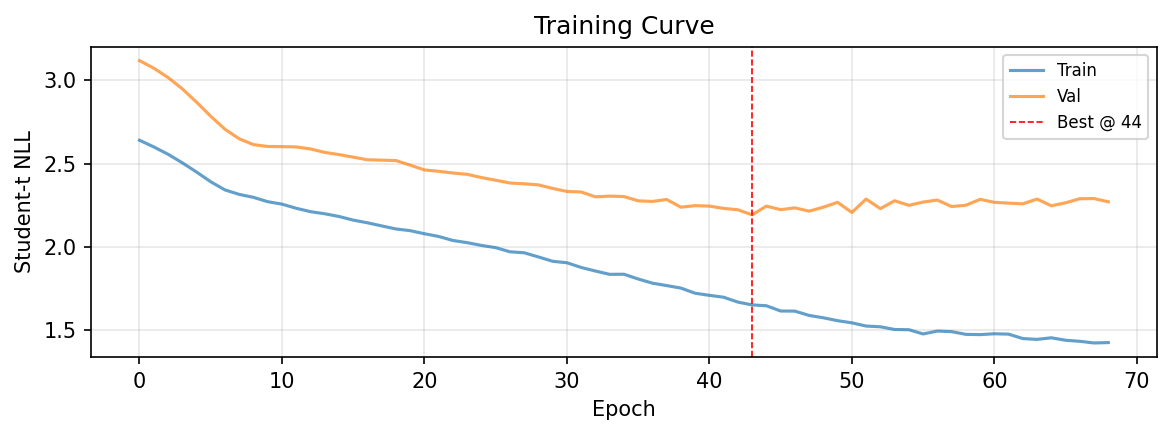

In [6]:
def make_bio_loaders(splits, bio_features, batch_size=256):
    loaders = {}
    for name, (X, y) in splits.items():
        f_bio = bio_features[name]
        ds = TensorDataset(X.float(), y.float(), f_bio.float())
        loaders[name] = DataLoader(ds, batch_size=batch_size, shuffle=(name == "train"))
    return loaders


loaders = make_bio_loaders(splits, bio_features)

EPOCHS = 200
LR = 3e-4
WD = 5e-4
PATIENCE = 25
NU = 3.0

model = MinimalUQModelV2(
    d_in=dim,
    d_hidden=64,
    d_trunk=32,
    dropout=0.15
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

best_val_loss = float("inf")
best_state = None
patience_counter = 0
best_epoch = 0
history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_n = 0.0, 0

    for X_b, y_b, bio_b in loaders["train"]:
        X_b, y_b, bio_b = X_b.to(DEVICE), y_b.to(DEVICE), bio_b.to(DEVICE)
        mu, sigma_alea, h = model(X_b, bio_b)
        loss = student_t_nll_loss(mu, sigma_alea, y_b, nu=NU)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * X_b.size(0)
        train_n += X_b.size(0)

    train_loss /= train_n

    model.eval()
    val_loss, val_n = 0.0, 0
    with torch.no_grad():
        for X_b, y_b, bio_b in loaders["val"]:
            X_b, y_b, bio_b = X_b.to(DEVICE), y_b.to(DEVICE), bio_b.to(DEVICE)
            mu, sigma_alea, h = model(X_b, bio_b)
            loss = student_t_nll_loss(mu, sigma_alea, y_b, nu=NU)
            val_loss += loss.item() * X_b.size(0)
            val_n += X_b.size(0)

    val_loss /= val_n

    history["train"].append(train_loss)
    history["val"].append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        best_epoch = epoch
    else:
        patience_counter += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f" Epoch {epoch:3d} | train {train_loss:.4f} | val {val_loss:.4f} | "
              f"best {best_val_loss:.4f} @ {best_epoch}")

    if patience_counter >= PATIENCE:
        print(f" Early stop at epoch {epoch} (best {best_val_loss:.4f} @ {best_epoch})")
        break

model.load_state_dict(best_state)
model.eval()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history["train"], label="Train", alpha=0.7)
ax.plot(history["val"], label="Val", alpha=0.7)
ax.axvline(best_epoch - 1, color="red", ls="--", lw=0.8, label=f"Best @ {best_epoch}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Student-t NLL")
ax.set_title("Training Curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "minimal_uq_training_v2.png")
plt.show()

## Density-Based Epistemic Uncertainty

$$\sigma_{\text{epi}}(x) = c \cdot \text{kNN\_dist}(h(x), H_{\text{train}})$$

Build kd-tree on training hidden reps, query for each test point.
Calibrate $c$ on validation set.

In [7]:
# K_NEIGHBORS = 5

# @torch.no_grad()
# def extract_hiddens(model, loader):
#     hs, mus, sigmas, ys = [], [], [], []
#     for X_b, y_b, bio_b in loader:
#         X_b, bio_b = X_b.to(DEVICE), bio_b.to(DEVICE)
#         mu, sigma_alea, h = model(X_b, bio_b)
#         hs.append(h.cpu().numpy())
#         mus.append(mu.cpu().numpy())
#         sigmas.append(sigma_alea.cpu().numpy())
#         ys.append(y_b.numpy())
#     return (np.concatenate(hs), np.concatenate(mus),
#             np.concatenate(sigmas), np.concatenate(ys))

# h_train, mu_train, sigma_train, y_train = extract_hiddens(model, loaders["train"])
# h_val, mu_val, sigma_val, y_val = extract_hiddens(model, loaders["val"])
# h_test, mu_test, sigma_test, y_test = extract_hiddens(model, loaders["test"])

# print(f"Hidden dim: {h_train.shape[1]}")

# # Build kd-tree
# tree = cKDTree(h_train)

# def knn_distance(h_query, k=K_NEIGHBORS):
#     dists, _ = tree.query(h_query, k=k)
#     return dists.mean(axis=1) if k > 1 else dists

# knn_dist_val = knn_distance(h_val)
# knn_dist_test = knn_distance(h_test)

# # Calibrate c on validation
# val_errors = np.abs(y_val - mu_val)
# val_residual = np.sqrt(np.maximum(val_errors**2 - sigma_val**2, 0))
# c_scale = np.median(val_residual) / np.maximum(np.median(knn_dist_val), 1e-6)
# print(f"Calibrated c = {c_scale:.4f}")

# sigma_epi_val = c_scale * knn_dist_val
# sigma_epi_test = c_scale * knn_dist_test

# sigma_total_val = np.sqrt(sigma_val**2 + sigma_epi_val**2)
# sigma_total_test = np.sqrt(sigma_test**2 + sigma_epi_test**2)

# test_errors = np.abs(y_test - mu_test)

# print(f"\n{'='*60}")
# print(f"Minimal UQ Model -- Test Results")
# print(f"{'='*60}")
# print(f"RMSE:                 {compute_rmse(mu_test, y_test):.4f}")
# print(f"MAE:                  {compute_mae(mu_test, y_test):.4f}")
# print(f"NLL (total):          {compute_gaussian_nll(mu_test, sigma_total_test, y_test):.4f}")
# ice_total, cov_total = compute_ice(mu_test, sigma_total_test, y_test)
# print(f"ICE (total):          {ice_total:.4f}")
# print(f"Coverage@90 (total):  {cov_total.get('0.90', 'N/A')}")
# print(f"corr(sig_total, err): {np.corrcoef(sigma_total_test, test_errors)[0,1]:.4f}")
# print(f"corr(sig_alea, err):  {np.corrcoef(sigma_test, test_errors)[0,1]:.4f}")
# print(f"corr(sig_epi, err):   {np.corrcoef(sigma_epi_test, test_errors)[0,1]:.4f}")
# print(f"Mean sig_alea:        {sigma_test.mean():.4f}")
# print(f"Mean sig_epi:         {sigma_epi_test.mean():.4f}")
# epi_frac = (sigma_epi_test**2 / (sigma_total_test**2).clip(1e-12)).mean()
# print(f"Epi fraction:         {epi_frac:.2%}")

In [8]:
K_NEIGHBORS = 10
LAMBDA_GRID = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]


@torch.no_grad()
def extract_hiddens(model, loader):
    hs, mus, sigmas, ys = [], [], [], []
    for X_b, y_b, bio_b in loader:
        X_b, bio_b = X_b.to(DEVICE), bio_b.to(DEVICE)
        mu, sigma_alea, h = model(X_b, bio_b)
        hs.append(h.cpu().numpy())
        mus.append(mu.cpu().numpy())
        sigmas.append(sigma_alea.cpu().numpy())
        ys.append(y_b.numpy())
    return (
        np.concatenate(hs),
        np.concatenate(mus),
        np.concatenate(sigmas),
        np.concatenate(ys),
    )


h_train, mu_train, sigma_train, y_train = extract_hiddens(model, loaders["train"])
h_val, mu_val, sigma_val, y_val = extract_hiddens(model, loaders["val"])
h_test, mu_test, sigma_test, y_test = extract_hiddens(model, loaders["test"])

print(f"Hidden dim: {h_train.shape[1]}")


# ---- whiten hidden space using train statistics ----
h_mean = h_train.mean(axis=0, keepdims=True)
h_std = h_train.std(axis=0, keepdims=True) + 1e-6

z_train = (h_train - h_mean) / h_std
z_val   = (h_val   - h_mean) / h_std
z_test  = (h_test  - h_mean) / h_std


# ---- kNN on whitened hidden space ----
tree = cKDTree(z_train)

def knn_distance(z_query, k=K_NEIGHBORS):
    dists, _ = tree.query(z_query, k=k)
    return dists.mean(axis=1) if k > 1 else dists


knn_val = knn_distance(z_val)
knn_test = knn_distance(z_test)


# ---- Mahalanobis in whitened space ----
# since z is standardized, plain squared norm already acts like a diagonal Mahalanobis proxy
maha_val = np.sum(z_val**2, axis=1)
maha_test = np.sum(z_test**2, axis=1)


def positive_zscore(x, ref):
    mu = np.mean(ref)
    sd = np.std(ref) + 1e-6
    return np.maximum((x - mu) / sd, 0.0)


# hybrid density score
dens_val = 0.5 * positive_zscore(knn_val, knn_val) + 0.5 * positive_zscore(maha_val, maha_val)
dens_test = 0.5 * positive_zscore(knn_test, knn_val) + 0.5 * positive_zscore(maha_test, maha_val)


# ---- validation grid search for density lambda ----
best_lambda = None
best_obj = float("inf")
best_val_stats = None

for lam in LAMBDA_GRID:
    sigma_epi_val = np.sqrt(lam * dens_val)
    sigma_total_val = np.sqrt(sigma_val**2 + sigma_epi_val**2)

    nll_val = compute_gaussian_nll(mu_val, sigma_total_val, y_val)
    ice_val, cov_val = compute_ice(mu_val, sigma_total_val, y_val)
    corr_val = np.corrcoef(sigma_total_val, np.abs(y_val - mu_val))[0, 1]

    # objective: prioritize NLL + ICE, reward discrimination a bit
    obj = nll_val + 0.5 * ice_val - 0.05 * np.nan_to_num(corr_val, nan=0.0)

    if obj < best_obj:
        best_obj = obj
        best_lambda = lam
        best_val_stats = (nll_val, ice_val, corr_val, cov_val)

print(f"Best density lambda = {best_lambda:.4f}")
print(f"Val NLL={best_val_stats[0]:.4f} | ICE={best_val_stats[1]:.4f} | "
      f"corr={best_val_stats[2]:.4f} | cov@90={best_val_stats[3].get('0.90', 'N/A')}")


# ---- test-time density epistemic ----
sigma_epi_val = np.sqrt(best_lambda * dens_val)
sigma_epi_test = np.sqrt(best_lambda * dens_test)

sigma_total_val = np.sqrt(sigma_val**2 + sigma_epi_val**2)
sigma_total_test = np.sqrt(sigma_test**2 + sigma_epi_test**2)

test_errors = np.abs(y_test - mu_test)

print(f"\n{'='*60}")
print("Minimal UQ Model v2 -- Test Results")
print(f"{'='*60}")
print(f"RMSE: {compute_rmse(mu_test, y_test):.4f}")
print(f"MAE: {compute_mae(mu_test, y_test):.4f}")
print(f"NLL (total): {compute_gaussian_nll(mu_test, sigma_total_test, y_test):.4f}")

ice_total, cov_total = compute_ice(mu_test, sigma_total_test, y_test)
print(f"ICE (total): {ice_total:.4f}")
print(f"Coverage@90 (total): {cov_total.get('0.90', 'N/A')}")
print(f"corr(sig_total, err): {np.corrcoef(sigma_total_test, test_errors)[0,1]:.4f}")
print(f"corr(sig_alea, err): {np.corrcoef(sigma_test, test_errors)[0,1]:.4f}")
print(f"corr(sig_epi, err): {np.corrcoef(sigma_epi_test, test_errors)[0,1]:.4f}")
print(f"Mean sig_alea: {sigma_test.mean():.4f}")
print(f"Mean sig_epi: {sigma_epi_test.mean():.4f}")

epi_frac = (sigma_epi_test**2 / (sigma_total_test**2).clip(1e-12)).mean()
print(f"Epi fraction: {epi_frac:.2%}")

Hidden dim: 32
Best density lambda = 1.0000
Val NLL=3.1646 | ICE=0.0893 | corr=-0.1784 | cov@90=0.7085377821393523

Minimal UQ Model v2 -- Test Results
RMSE: 1.3930
MAE: 0.9668
NLL (total): 1.8107
ICE (total): 0.0878
Coverage@90 (total): 0.9058823529411765
corr(sig_total, err): -0.0196
corr(sig_alea, err): -0.1828
corr(sig_epi, err): 0.0916
Mean sig_alea: 1.0638
Mean sig_epi: 0.9303
Epi fraction: 40.51%


## Minimal Version — Visualization

In [9]:
# fig = plt.figure(figsize=(18, 12))
# gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

# # 1. Calibration
# ax = fig.add_subplot(gs[0, 0])
# ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Ideal")
# for sigma_arr, label, color in [
#     (sigma_test, "sig_alea only", "#2563eb"),
#     (sigma_total_test, "sig_total", "#dc2626"),
# ]:
#     nom, emp = compute_coverage_curve(mu_test, sigma_arr, y_test)
#     ax.plot(nom, emp, "o-", ms=3, lw=1.5, color=color, label=label)
# ax.set_xlabel("Expected"); ax.set_ylabel("Observed")
# ax.set_title(f"Calibration (ICE={ice_total:.3f})")
# ax.legend(fontsize=8); ax.set_aspect("equal")
# ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# # 2. sig_alea vs sig_epi
# ax = fig.add_subplot(gs[0, 1])
# sc = ax.scatter(sigma_test, sigma_epi_test, c=test_errors, cmap="RdYlGn_r",
#                 s=15, alpha=0.6, edgecolor="none")
# ax.set_xlabel("sig_alea"); ax.set_ylabel("sig_epi")
# ax.set_title("Aleatoric vs Epistemic")
# plt.colorbar(sc, ax=ax, label="|error|", shrink=0.8)

# # 3. sig_total vs |error|
# ax = fig.add_subplot(gs[0, 2])
# ax.scatter(sigma_total_test, test_errors, alpha=0.4, s=12, c="#2563eb", edgecolor="none")
# r_total = np.corrcoef(sigma_total_test, test_errors)[0, 1]
# z = np.polyfit(sigma_total_test, test_errors, 1)
# xs = np.linspace(sigma_total_test.min(), sigma_total_test.max(), 50)
# ax.plot(xs, np.polyval(z, xs), "r-", lw=1.5, alpha=0.7)
# ax.set_xlabel("sig_total"); ax.set_ylabel("|error|")
# ax.set_title(f"sig_total vs Error (r={r_total:.3f})")

# # 4. kNN distance distribution
# ax = fig.add_subplot(gs[1, 0])
# ax.hist(knn_dist_test, bins=30, color="#f59e0b", alpha=0.7, edgecolor="white", label="Test")
# ax.hist(knn_dist_val, bins=30, color="#2563eb", alpha=0.4, edgecolor="white", label="Val")
# ax.set_xlabel("kNN distance (hidden space)"); ax.set_ylabel("Count")
# ax.set_title("Distance to Training Data"); ax.legend()

# # 5. Error by quintile
# ax = fig.add_subplot(gs[1, 1])
# q_labels = ["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"]
# try:
#     sigma_q = pd.qcut(sigma_total_test, 5, labels=q_labels, duplicates="drop")
#     df_q = pd.DataFrame({"q": sigma_q, "err": test_errors,
#                           "alea": sigma_test, "epi": sigma_epi_test})
#     grp = df_q.groupby("q", observed=True)
#     actual_labels = list(grp["err"].mean().index)
#     x_q = np.arange(len(actual_labels))
#     w = 0.25
#     ax.bar(x_q - w, grp["err"].mean(), w, label="|error|", color="#dc2626", alpha=0.8)
#     ax.bar(x_q, grp["alea"].mean(), w, label="sig_alea", color="#2563eb", alpha=0.8)
#     ax.bar(x_q + w, grp["epi"].mean(), w, label="sig_epi", color="#f59e0b", alpha=0.8)
#     ax.set_xticks(x_q); ax.set_xticklabels(actual_labels, fontsize=8)
# except ValueError:
#     ax.text(0.5, 0.5, "Too few unique values", ha="center", va="center", transform=ax.transAxes)
# ax.set_ylabel("Value"); ax.set_title("Error & Uncertainty by Quintile")
# ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

# # 6. RSA
# ax = fig.add_subplot(gs[1, 2])
# test_meta = meta_df[meta_df["split"] == "test"].reset_index(drop=True)
# if "rel_rsa" in test_meta.columns and len(test_meta) == len(y_test):
#     rsa = test_meta["rel_rsa"].values
#     rsa_bins = pd.cut(rsa, bins=[-0.001, 0.2, 0.5, 1.0], labels=["Buried", "Inter.", "Exposed"])
#     df_rsa = pd.DataFrame({"rsa": rsa_bins, "err": test_errors,
#                             "alea": sigma_test, "epi": sigma_epi_test}).dropna(subset=["rsa"])
#     grp = df_rsa.groupby("rsa", observed=True)
#     gl = list(grp["err"].mean().index)
#     xr = np.arange(len(gl)); w = 0.25
#     ax.bar(xr - w, grp["err"].mean(), w, label="|error|", color="#dc2626", alpha=0.8)
#     ax.bar(xr, grp["alea"].mean(), w, label="sig_alea", color="#2563eb", alpha=0.8)
#     ax.bar(xr + w, grp["epi"].mean(), w, label="sig_epi", color="#f59e0b", alpha=0.8)
#     ax.set_xticks(xr); ax.set_xticklabels(gl)
#     ax.set_title("RSA x Uncertainty"); ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)
# else:
#     ax.text(0.5, 0.5, "RSA N/A", ha="center", va="center", transform=ax.transAxes)

# plt.suptitle("Part 1 -- Minimal UQ Model (Density-Based Epistemic)",
#              fontsize=14, fontweight="bold", y=1.01)
# plt.savefig(FIG_DIR / "minimal_uq_analysis.png")
# plt.show()

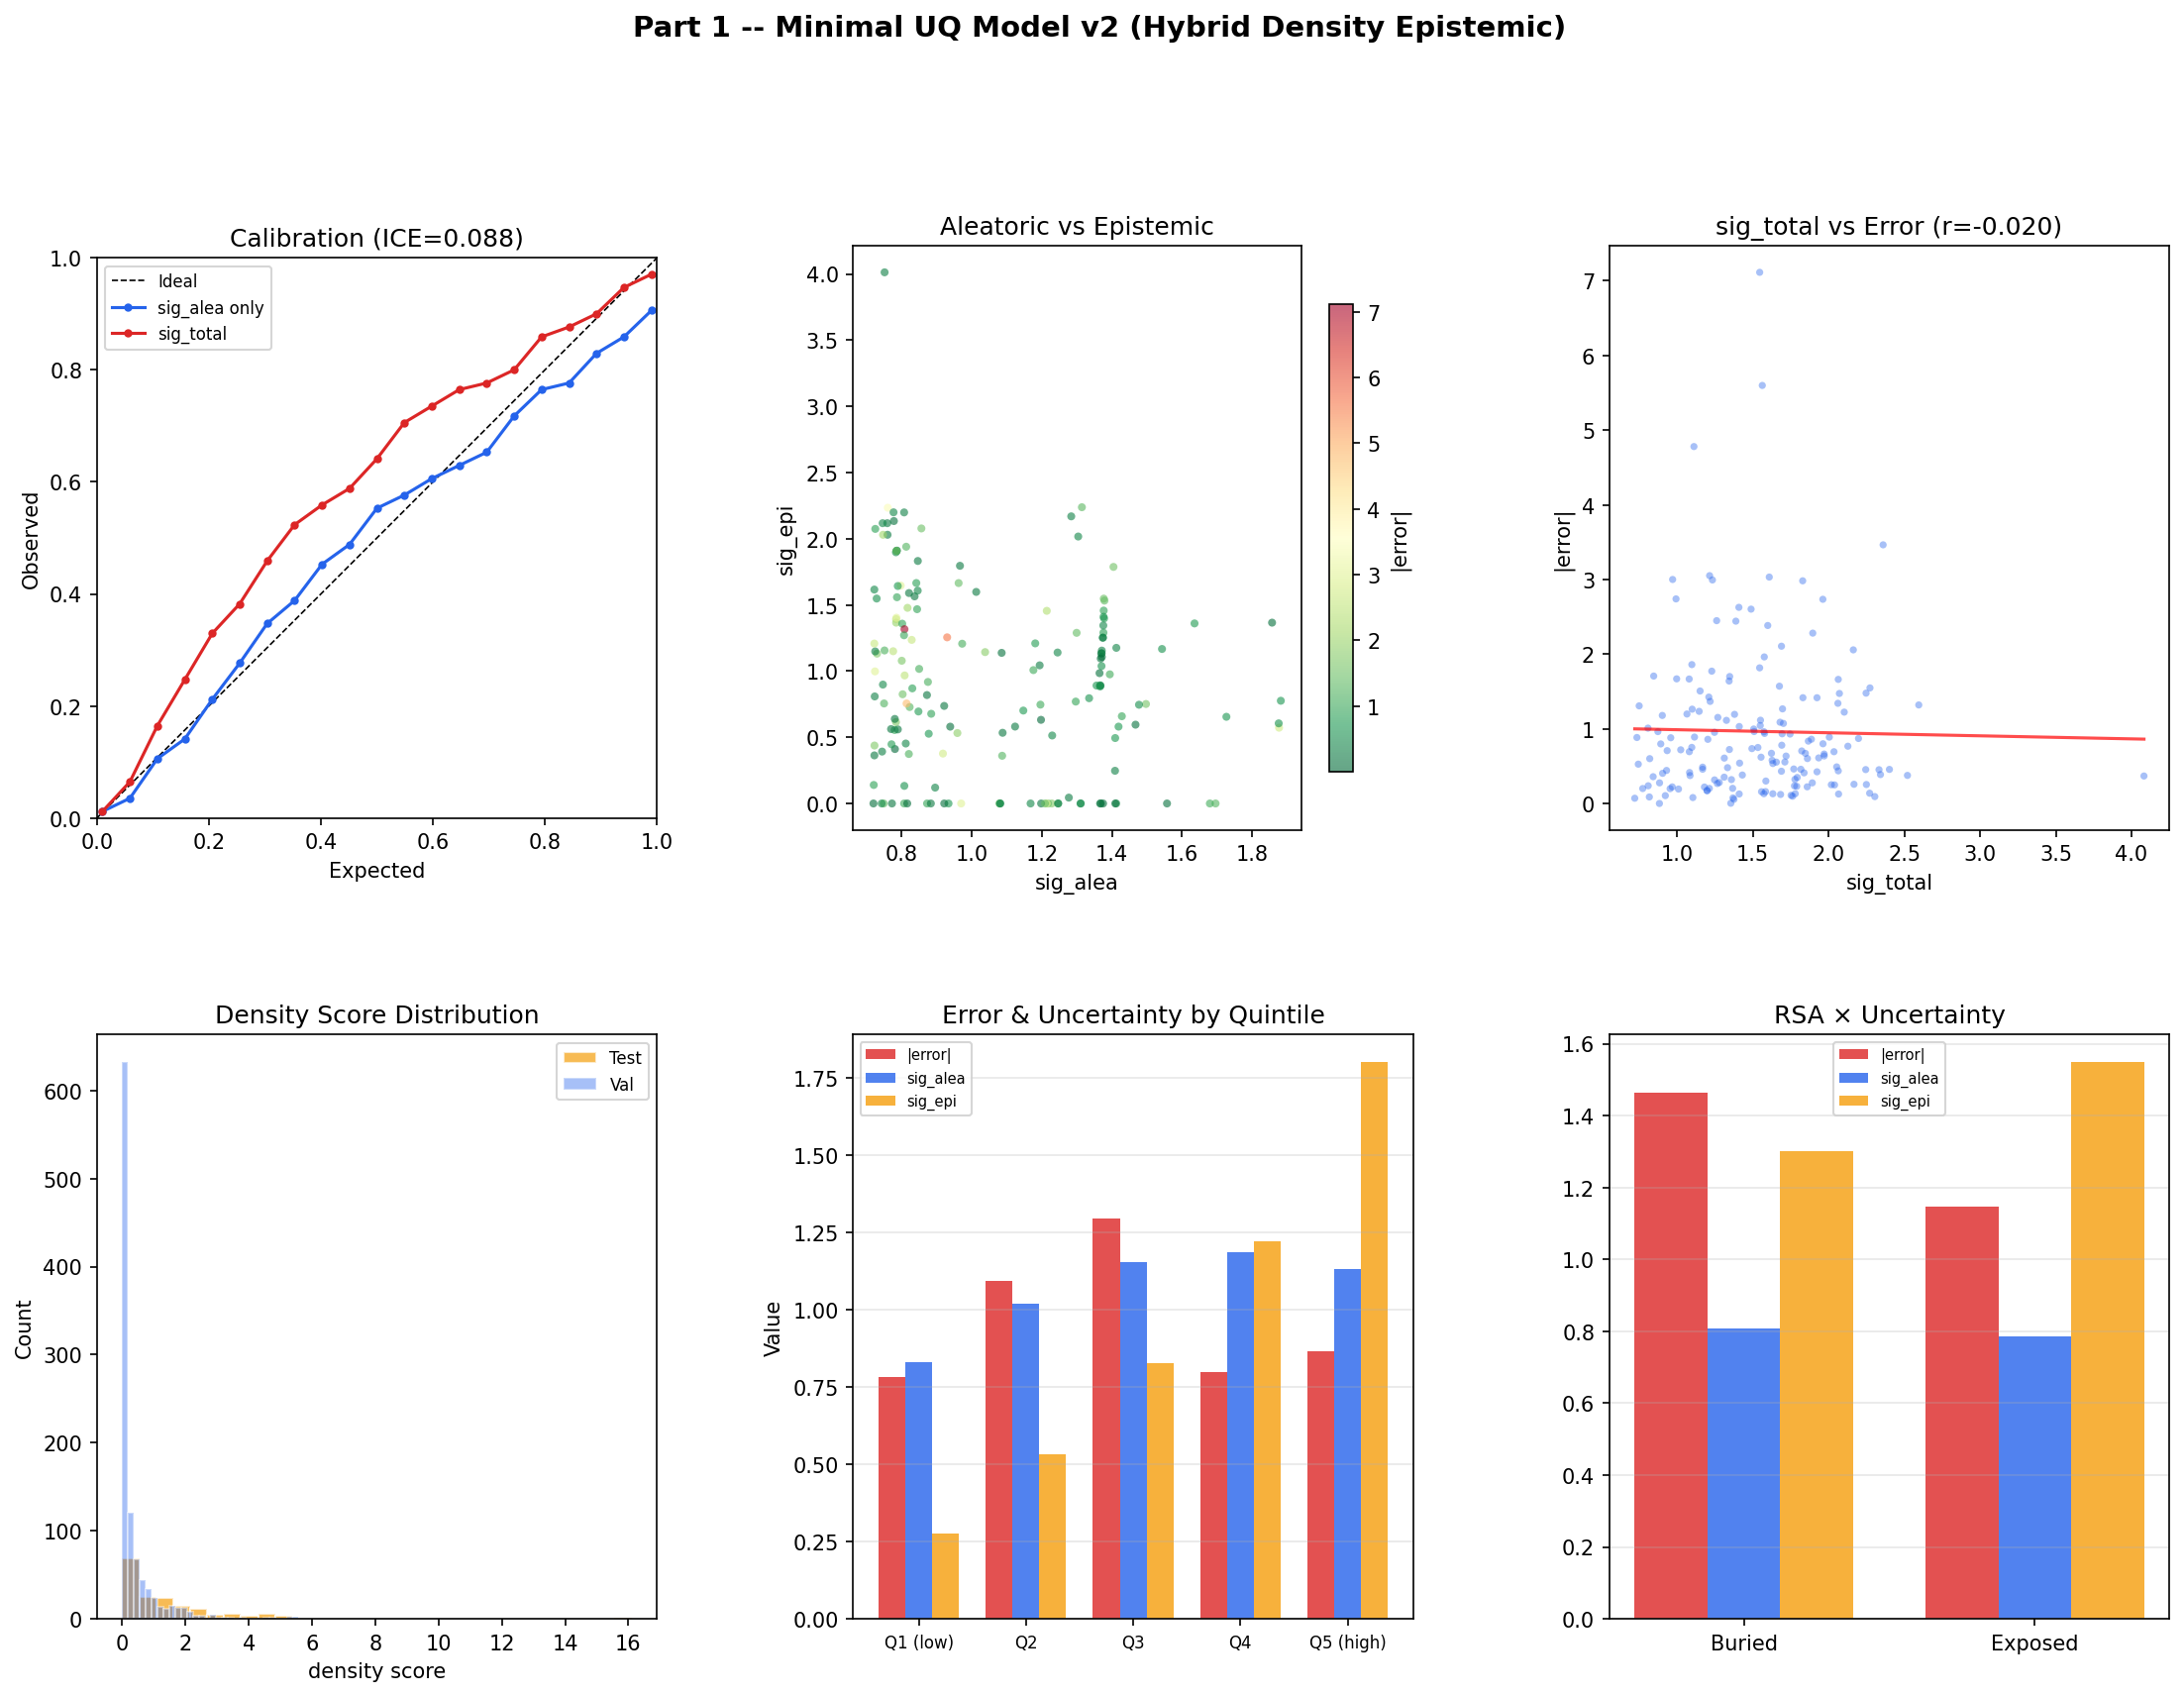

In [10]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

# 1. Calibration
ax = fig.add_subplot(gs[0, 0])
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Ideal")
for sigma_arr, label, color in [
    (sigma_test, "sig_alea only", "#2563eb"),
    (sigma_total_test, "sig_total", "#dc2626"),
]:
    nom, emp = compute_coverage_curve(mu_test, sigma_arr, y_test)
    ax.plot(nom, emp, "o-", ms=3, lw=1.5, color=color, label=label)
ax.set_xlabel("Expected")
ax.set_ylabel("Observed")
ax.set_title(f"Calibration (ICE={ice_total:.3f})")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 2. sig_alea vs sig_epi
ax = fig.add_subplot(gs[0, 1])
sc = ax.scatter(sigma_test, sigma_epi_test, c=test_errors, cmap="RdYlGn_r",
                s=15, alpha=0.6, edgecolor="none")
ax.set_xlabel("sig_alea")
ax.set_ylabel("sig_epi")
ax.set_title("Aleatoric vs Epistemic")
plt.colorbar(sc, ax=ax, label="|error|", shrink=0.8)

# 3. sig_total vs |error|
ax = fig.add_subplot(gs[0, 2])
ax.scatter(sigma_total_test, test_errors, alpha=0.4, s=12, c="#2563eb", edgecolor="none")
r_total = np.corrcoef(sigma_total_test, test_errors)[0, 1]
z = np.polyfit(sigma_total_test, test_errors, 1)
xs = np.linspace(sigma_total_test.min(), sigma_total_test.max(), 50)
ax.plot(xs, np.polyval(z, xs), "r-", lw=1.5, alpha=0.7)
ax.set_xlabel("sig_total")
ax.set_ylabel("|error|")
ax.set_title(f"sig_total vs Error (r={r_total:.3f})")

# 4. Density score distribution
ax = fig.add_subplot(gs[1, 0])
ax.hist(dens_test, bins=30, color="#f59e0b", alpha=0.7, edgecolor="white", label="Test")
ax.hist(dens_val, bins=30, color="#2563eb", alpha=0.4, edgecolor="white", label="Val")
ax.set_xlabel("density score")
ax.set_ylabel("Count")
ax.set_title("Density Score Distribution")
ax.legend()

# 5. Error by quintile
ax = fig.add_subplot(gs[1, 1])
q_labels = ["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"]
sigma_q = pd.qcut(sigma_total_test, 5, labels=q_labels, duplicates="drop")
df_q = pd.DataFrame({
    "q": sigma_q,
    "err": test_errors,
    "alea": sigma_test,
    "epi": sigma_epi_test
})
grp = df_q.groupby("q", observed=True)
actual_labels = list(grp["err"].mean().index)
x_q = np.arange(len(actual_labels))
w = 0.25
ax.bar(x_q - w, grp["err"].mean(), w, label="|error|", color="#dc2626", alpha=0.8)
ax.bar(x_q, grp["alea"].mean(), w, label="sig_alea", color="#2563eb", alpha=0.8)
ax.bar(x_q + w, grp["epi"].mean(), w, label="sig_epi", color="#f59e0b", alpha=0.8)
ax.set_xticks(x_q)
ax.set_xticklabels(actual_labels, fontsize=8)
ax.set_ylabel("Value")
ax.set_title("Error & Uncertainty by Quintile")
ax.legend(fontsize=7)
ax.grid(axis="y", alpha=0.3)

# 6. RSA
ax = fig.add_subplot(gs[1, 2])
test_meta = meta_df[meta_df["split"] == "test"].reset_index(drop=True)
if "rel_rsa" in test_meta.columns and len(test_meta) == len(y_test):
    rsa = test_meta["rel_rsa"].values
    rsa_bins = pd.cut(rsa, bins=[-0.001, 0.2, 0.5, 1.0], labels=["Buried", "Inter.", "Exposed"])
    df_rsa = pd.DataFrame({
        "rsa": rsa_bins,
        "err": test_errors,
        "alea": sigma_test,
        "epi": sigma_epi_test
    }).dropna(subset=["rsa"])
    grp = df_rsa.groupby("rsa", observed=True)
    gl = list(grp["err"].mean().index)
    xr = np.arange(len(gl))
    w = 0.25
    ax.bar(xr - w, grp["err"].mean(), w, label="|error|", color="#dc2626", alpha=0.8)
    ax.bar(xr, grp["alea"].mean(), w, label="sig_alea", color="#2563eb", alpha=0.8)
    ax.bar(xr + w, grp["epi"].mean(), w, label="sig_epi", color="#f59e0b", alpha=0.8)
    ax.set_xticks(xr)
    ax.set_xticklabels(gl)
    ax.set_title("RSA × Uncertainty")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "RSA N/A", ha="center", va="center", transform=ax.transAxes)

plt.suptitle("Part 1 -- Minimal UQ Model v2 (Hybrid Density Epistemic)",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(FIG_DIR / "minimal_uq_analysis_v2.png")
plt.show()

---
# Part 2 — Recommended Model: Laplace Last-Layer

After MAP training, compute the Hessian of the last-layer loss:

1. Posterior precision: $\Lambda = \alpha I + N \cdot H$
2. Posterior covariance: $\Sigma = \Lambda^{-1}$
3. Predictive variance: $\sigma^2_{\text{Laplace}}(x) = h(x)^\top \Sigma\, h(x)$

Combined epistemic:
$$\sigma^2_{\text{epi}}(x) = \sigma^2_{\text{Laplace}}(x) + \lambda \cdot \text{kNN\_dist}^2$$

In [11]:
class LaplaceLastLayer:
    '''Post-hoc Laplace approximation on the linear mu head.'''

    def __init__(self, model, prior_precision=1.0):
        self.model = model
        self.prior_precision = prior_precision
        self.W_map = model.mu_head.weight.data.cpu().clone()
        self.b_map = model.mu_head.bias.data.cpu().clone()
        self.d = self.W_map.shape[1]
        self.Sigma = None

    def fit(self, train_loader):
        '''Compute posterior covariance from training data.'''
        self.model.eval()
        H = torch.zeros(self.d, self.d)
        N = 0
        with torch.no_grad():
            for X_b, y_b, bio_b in train_loader:
                X_b, bio_b = X_b.to(DEVICE), bio_b.to(DEVICE)
                mu, sigma_alea, h = self.model(X_b, bio_b)
                h_cpu = h.cpu()
                sigma_cpu = sigma_alea.cpu()
                weights = 1.0 / (sigma_cpu ** 2 + 1e-8)
                h_w = h_cpu * weights.unsqueeze(-1).sqrt()
                H += h_w.T @ h_w
                N += X_b.size(0)
        H /= N
        Lambda = self.prior_precision * torch.eye(self.d) + N * H
        try:
            L = torch.linalg.cholesky(Lambda)
            self.Sigma = torch.cholesky_inverse(L)
        except torch.linalg.LinAlgError:
            Lambda += 1e-4 * torch.eye(self.d)
            L = torch.linalg.cholesky(Lambda)
            self.Sigma = torch.cholesky_inverse(L)
        print(f"  Laplace fit: d={self.d}, N={N}")
        print(f"  Sigma trace: {self.Sigma.trace().item():.6f}")
        print(f"  Sigma max eigenval: {torch.linalg.eigvalsh(self.Sigma)[-1].item():.6f}")

    def predict_variance(self, h):
        '''h: (N, d) numpy -> (N,) numpy of laplace variances.'''
        h_t = torch.from_numpy(h).float()
        Sh = h_t @ self.Sigma
        var = (Sh * h_t).sum(dim=-1).numpy()
        return np.maximum(var, 0.0)

laplace = LaplaceLastLayer(model, prior_precision=1.0)
laplace.fit(loaders["train"])

  Laplace fit: d=32, N=1395
  Sigma trace: 9.480946
  Sigma max eigenval: 1.000000


## Full Predictive Distribution — Comparison

In [12]:
# laplace_var_test = laplace.predict_variance(h_test)
# sigma_laplace_test = np.sqrt(laplace_var_test)

# LAMBDA_DENSITY = 0.5
# sigma_epi_full_test = np.sqrt(laplace_var_test + LAMBDA_DENSITY * knn_dist_test**2)
# sigma_full_test = np.sqrt(sigma_test**2 + sigma_epi_full_test**2)

# configs = {
#     "sig_alea only":        (mu_test, sigma_test, y_test),
#     "sig_alea + kNN":       (mu_test, sigma_total_test, y_test),
#     "sig_alea + Laplace":   (mu_test, np.sqrt(sigma_test**2 + laplace_var_test), y_test),
#     "sig_alea + Lap + kNN": (mu_test, sigma_full_test, y_test),
# }

# rows = []
# for name, (mu, sigma, y) in configs.items():
#     ice, cov = compute_ice(mu, sigma, y)
#     errs = np.abs(y - mu)
#     rows.append({
#         "config": name,
#         "RMSE": round(compute_rmse(mu, y), 4),
#         "NLL": round(compute_gaussian_nll(mu, sigma, y), 4),
#         "ICE": round(ice, 4),
#         "cov@90": round(float(cov.get("0.90", 0)), 3),
#         "corr(sig,err)": round(float(np.corrcoef(sigma, errs)[0, 1]), 4),
#         "mean_sig": round(float(sigma.mean()), 4),
#     })

# df_compare = pd.DataFrame(rows)
# print("=" * 75)
# print("Uncertainty Configuration Comparison")
# print("=" * 75)
# print(df_compare.to_string(index=False))
# df_compare.to_csv(FIG_DIR / "laplace_comparison.csv", index=False)

In [13]:
class LaplaceLastLayer:
    """Post-hoc Laplace approximation on the linear mu head."""
    def __init__(self, model, prior_precision=1.0):
        self.model = model
        self.prior_precision = prior_precision
        self.W_map = model.mu_head.weight.data.cpu().clone()
        self.b_map = model.mu_head.bias.data.cpu().clone()
        self.d = self.W_map.shape[1]
        self.Sigma = None

    def fit(self, train_loader):
        self.model.eval()
        H = torch.zeros(self.d, self.d)
        N = 0
        with torch.no_grad():
            for X_b, y_b, bio_b in train_loader:
                X_b, bio_b = X_b.to(DEVICE), bio_b.to(DEVICE)
                mu, sigma_alea, h = self.model(X_b, bio_b)
                h_cpu = h.cpu()
                sigma_cpu = sigma_alea.cpu()
                weights = 1.0 / (sigma_cpu ** 2 + 1e-8)
                h_w = h_cpu * weights.unsqueeze(-1).sqrt()
                H += h_w.T @ h_w
                N += X_b.size(0)

        H /= N
        Lambda = self.prior_precision * torch.eye(self.d) + N * H

        try:
            L = torch.linalg.cholesky(Lambda)
            self.Sigma = torch.cholesky_inverse(L)
        except torch.linalg.LinAlgError:
            Lambda += 1e-4 * torch.eye(self.d)
            L = torch.linalg.cholesky(Lambda)
            self.Sigma = torch.cholesky_inverse(L)

        print(f" Laplace fit: d={self.d}, N={N}")
        print(f" Sigma trace: {self.Sigma.trace().item():.6f}")
        print(f" Sigma max eigenval: {torch.linalg.eigvalsh(self.Sigma)[-1].item():.6f}")

    def predict_variance(self, h):
        h_t = torch.from_numpy(h).float()
        Sh = h_t @ self.Sigma
        var = (Sh * h_t).sum(dim=-1).numpy()
        return np.maximum(var, 0.0)


laplace = LaplaceLastLayer(model, prior_precision=1.0)
laplace.fit(loaders["train"])

laplace_var_val = laplace.predict_variance(h_val)
laplace_var_test = laplace.predict_variance(h_test)

sigma_laplace_val = np.sqrt(laplace_var_val)
sigma_laplace_test = np.sqrt(laplace_var_test)


# ---- tune density weight on validation, now on top of Laplace ----
LAMBDA_GRID = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

best_lambda = None
best_obj = float("inf")

for lam in LAMBDA_GRID:
    sigma_epi_full_val = np.sqrt(laplace_var_val + lam * dens_val)
    sigma_full_val = np.sqrt(sigma_val**2 + sigma_epi_full_val**2)

    nll_val = compute_gaussian_nll(mu_val, sigma_full_val, y_val)
    ice_val, cov_val = compute_ice(mu_val, sigma_full_val, y_val)
    corr_val = np.corrcoef(sigma_full_val, np.abs(y_val - mu_val))[0, 1]

    obj = nll_val + 0.5 * ice_val - 0.05 * np.nan_to_num(corr_val, nan=0.0)

    if obj < best_obj:
        best_obj = obj
        best_lambda = lam
        best_val_stats = (nll_val, ice_val, corr_val, cov_val)

print(f"Best Laplace+density lambda = {best_lambda:.4f}")
print(f"Val NLL={best_val_stats[0]:.4f} | ICE={best_val_stats[1]:.4f} | "
      f"corr={best_val_stats[2]:.4f} | cov@90={best_val_stats[3].get('0.90', 'N/A')}")


sigma_density_test = np.sqrt(best_lambda * dens_test)
sigma_epi_full_test = np.sqrt(laplace_var_test + best_lambda * dens_test)
sigma_full_test = np.sqrt(sigma_test**2 + sigma_epi_full_test**2)

configs = {
    "sig_alea only": (mu_test, sigma_test, y_test),
    "sig_alea + density_v2": (mu_test, np.sqrt(sigma_test**2 + best_lambda * dens_test), y_test),
    "sig_alea + Laplace": (mu_test, np.sqrt(sigma_test**2 + laplace_var_test), y_test),
    "sig_alea + Lap + density_v2": (mu_test, sigma_full_test, y_test),
}

rows = []
for name, (mu, sigma, y) in configs.items():
    ice, cov = compute_ice(mu, sigma, y)
    errs = np.abs(y - mu)
    rows.append({
        "config": name,
        "RMSE": round(compute_rmse(mu, y), 4),
        "NLL": round(compute_gaussian_nll(mu, sigma, y), 4),
        "ICE": round(ice, 4),
        "cov@90": round(float(cov.get("0.90", 0)), 3),
        "corr(sig,err)": round(float(np.corrcoef(sigma, errs)[0, 1]), 4),
        "mean_sig": round(float(sigma.mean()), 4),
    })

df_compare = pd.DataFrame(rows)
print("=" * 75)
print("Uncertainty Configuration Comparison -- v2")
print("=" * 75)
print(df_compare.to_string(index=False))

df_compare.to_csv(FIG_DIR / "laplace_comparison_v2.csv", index=False)

 Laplace fit: d=32, N=1395
 Sigma trace: 9.480913
 Sigma max eigenval: 1.000000
Best Laplace+density lambda = 1.0000
Val NLL=3.1490 | ICE=0.0886 | corr=-0.1783 | cov@90=0.7095191364082434
Uncertainty Configuration Comparison -- v2
                     config  RMSE    NLL    ICE  cov@90  corr(sig,err)  mean_sig
              sig_alea only 1.393 2.2073 0.0351   0.829        -0.1828    1.0638
      sig_alea + density_v2 1.393 1.8107 0.0878   0.906        -0.0196    1.5299
         sig_alea + Laplace 1.393 2.1865 0.0349   0.829        -0.1819    1.0707
sig_alea + Lap + density_v2 1.393 1.8101 0.0884   0.906        -0.0193    1.5343


## Final Comparison Visualization

In [14]:
# fig = plt.figure(figsize=(18, 10))
# gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

# palette = {"sig_alea only": "#93c5fd", "sig_alea + kNN": "#f59e0b",
#            "sig_alea + Laplace": "#7c3aed", "sig_alea + Lap + kNN": "#dc2626"}

# # 1. Calibration
# ax = fig.add_subplot(gs[0, 0])
# ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Ideal")
# for name, (mu, sigma, y) in configs.items():
#     nom, emp = compute_coverage_curve(mu, sigma, y)
#     ax.plot(nom, emp, "o-", ms=3, lw=1.5, color=palette[name], label=name)
# ax.set_xlabel("Expected"); ax.set_ylabel("Observed")
# ax.set_title("Calibration Comparison")
# ax.legend(fontsize=7); ax.set_aspect("equal")
# ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# # 2. ICE bars
# ax = fig.add_subplot(gs[0, 1])
# x = np.arange(len(df_compare))
# ax.barh(x, df_compare["ICE"], color=[palette[n] for n in df_compare["config"]], alpha=0.85)
# ax.set_yticks(x); ax.set_yticklabels(df_compare["config"], fontsize=9)
# ax.set_xlabel("ICE (lower = better)"); ax.set_title("Calibration Error")
# ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)

# # 3. corr bars
# ax = fig.add_subplot(gs[0, 2])
# ax.barh(x, df_compare["corr(sig,err)"], color=[palette[n] for n in df_compare["config"]], alpha=0.85)
# ax.set_yticks(x); ax.set_yticklabels(df_compare["config"], fontsize=9)
# ax.set_xlabel("corr(sig, |error|)"); ax.set_title("Uncertainty Discrimination")
# ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)

# # 4. Decomposition scatter
# ax = fig.add_subplot(gs[1, 0])
# sc = ax.scatter(sigma_test, sigma_epi_full_test, c=test_errors, cmap="RdYlGn_r",
#            s=15, alpha=0.6, edgecolor="none")
# ax.set_xlabel("sig_alea"); ax.set_ylabel("sig_epi (Laplace + kNN)")
# ax.set_title("Uncertainty Decomposition")
# plt.colorbar(sc, ax=ax, shrink=0.8, label="|error|")

# # 5. Laplace vs kNN
# ax = fig.add_subplot(gs[1, 1])
# ax.scatter(sigma_laplace_test, sigma_epi_test, alpha=0.4, s=12, c="#7c3aed", edgecolor="none")
# ax.set_xlabel("sig_Laplace"); ax.set_ylabel("sig_kNN")
# ax.set_title("Laplace vs Density Epistemic")
# ax.axline((0, 0), slope=1, color="gray", ls="--", lw=0.8)

# # 6. Component means
# ax = fig.add_subplot(gs[1, 2])
# components = {"sig_alea": sigma_test.mean(), "sig_Laplace": sigma_laplace_test.mean(),
#               "sig_kNN": sigma_epi_test.mean(), "sig_total": sigma_full_test.mean()}
# colors_comp = ["#2563eb", "#7c3aed", "#f59e0b", "#dc2626"]
# bars = ax.bar(components.keys(), components.values(), color=colors_comp, alpha=0.85)
# ax.set_ylabel("Mean sigma"); ax.set_title("Average Uncertainty Components")
# ax.grid(axis="y", alpha=0.3)
# for i, (k, v) in enumerate(components.items()):
#     ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

# plt.suptitle("Recommended Model -- Student-t + Laplace + Density Epistemic",
#              fontsize=14, fontweight="bold", y=1.01)
# plt.savefig(FIG_DIR / "recommended_model_analysis.png")
# plt.show()

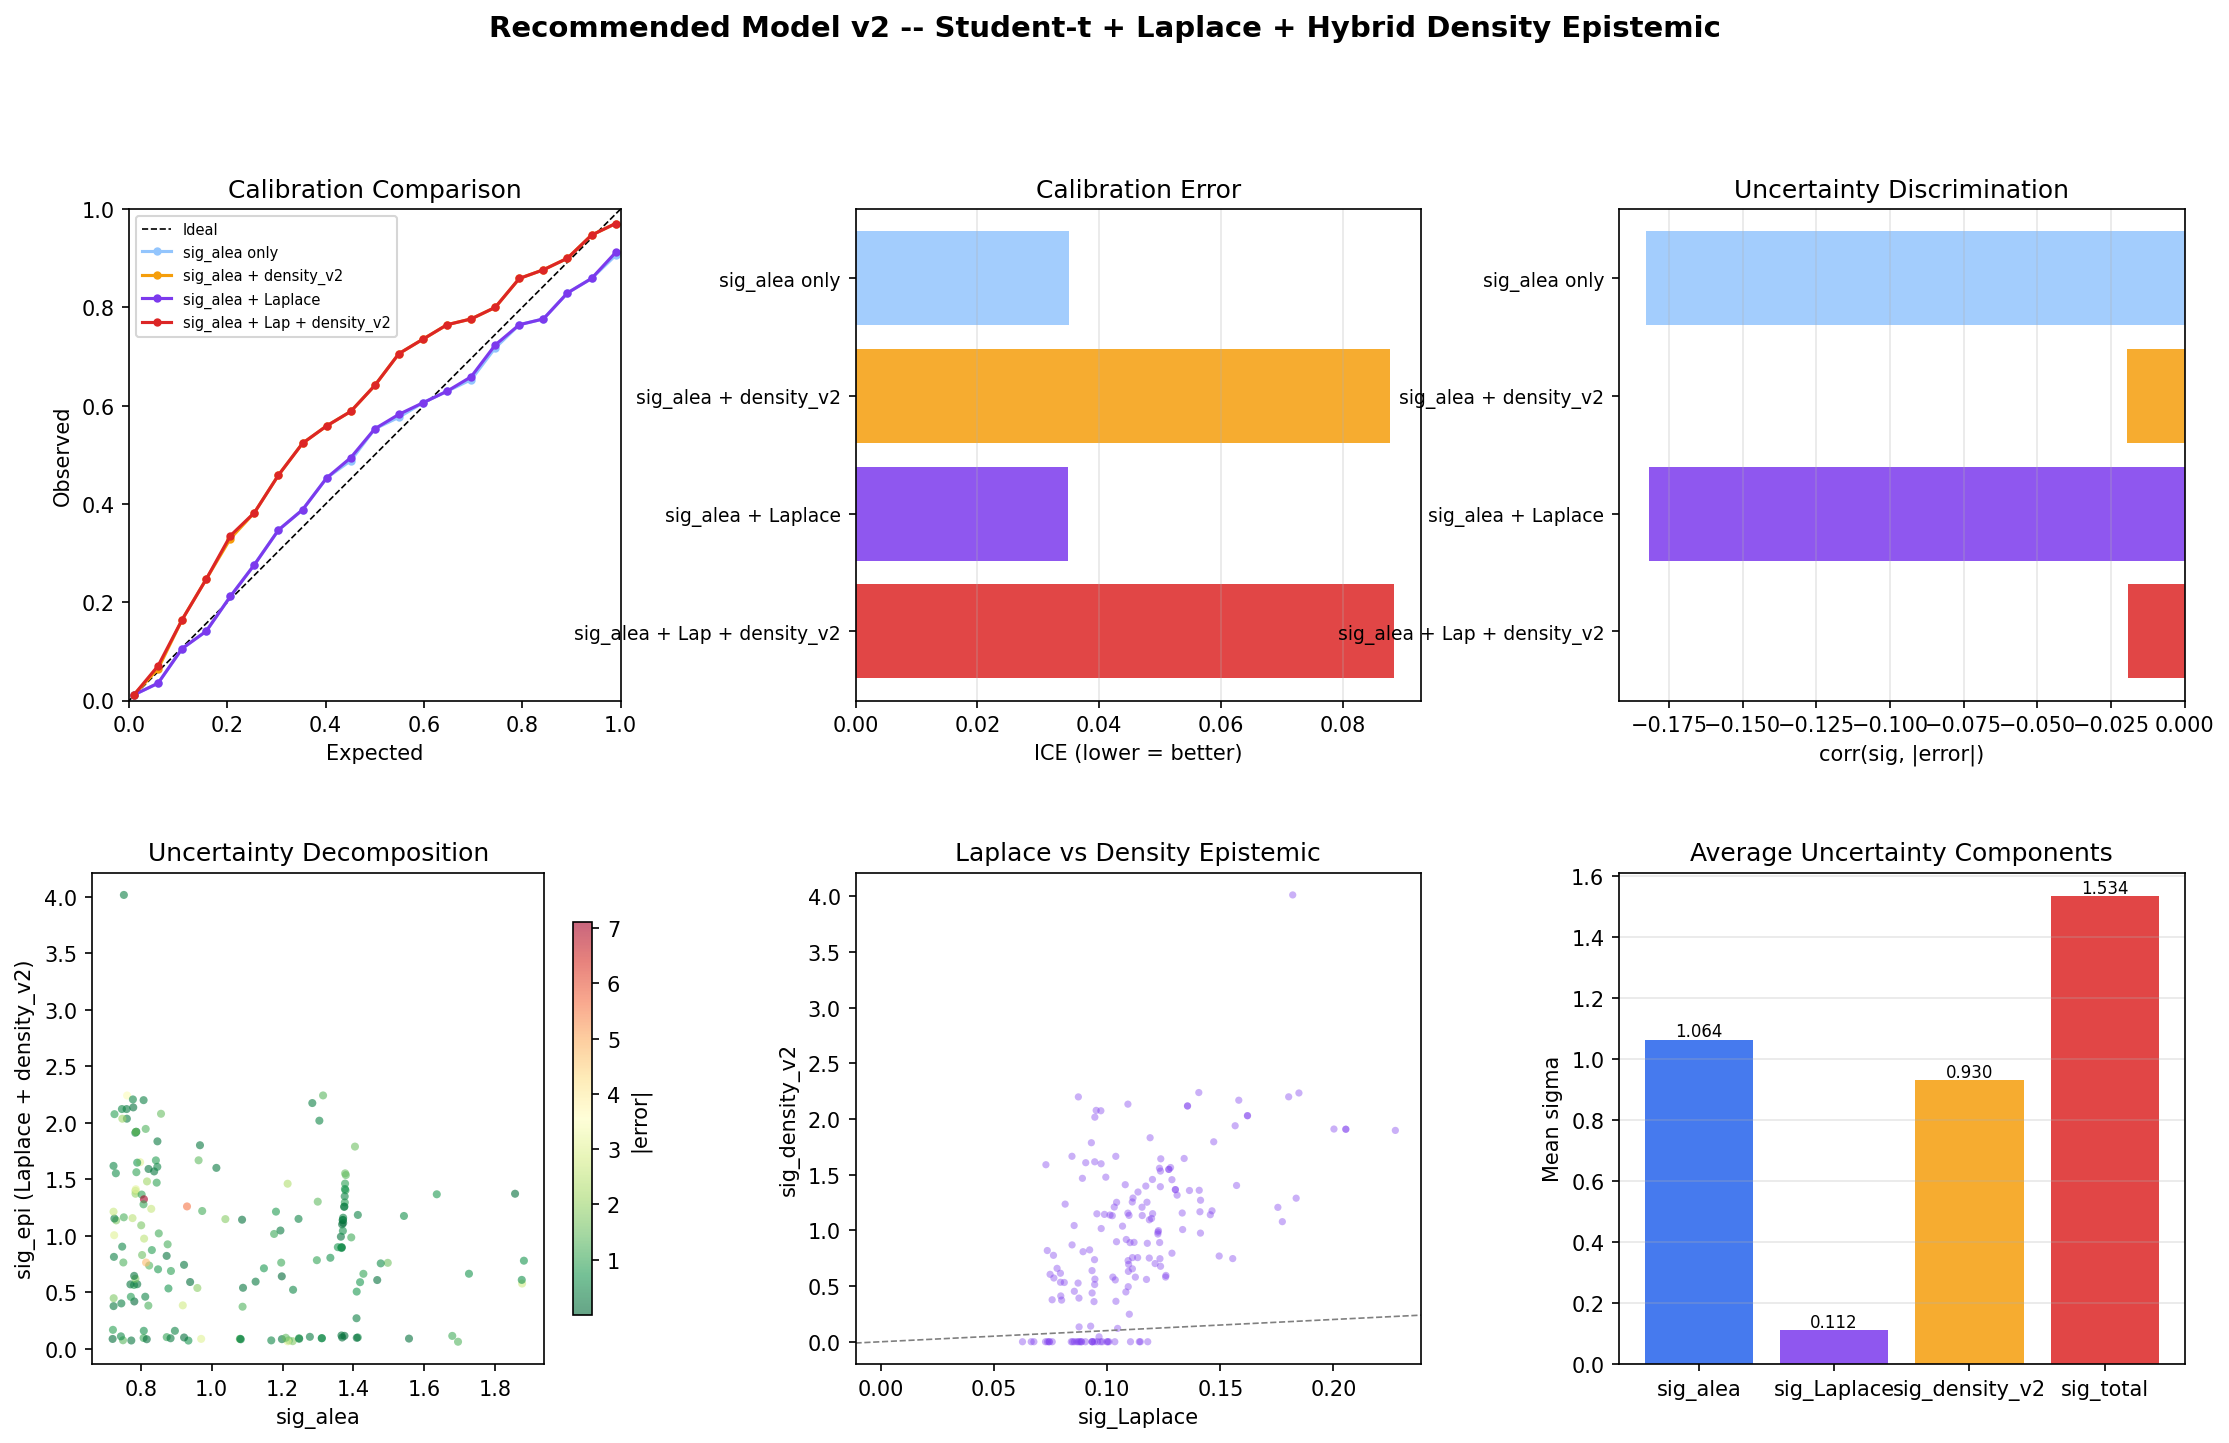

In [15]:
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

palette = {
    "sig_alea only": "#93c5fd",
    "sig_alea + density_v2": "#f59e0b",
    "sig_alea + Laplace": "#7c3aed",
    "sig_alea + Lap + density_v2": "#dc2626",
}

# 1. Calibration
ax = fig.add_subplot(gs[0, 0])
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Ideal")
for name, (mu, sigma, y) in configs.items():
    nom, emp = compute_coverage_curve(mu, sigma, y)
    ax.plot(nom, emp, "o-", ms=3, lw=1.5, color=palette[name], label=name)
ax.set_xlabel("Expected")
ax.set_ylabel("Observed")
ax.set_title("Calibration Comparison")
ax.legend(fontsize=7)
ax.set_aspect("equal")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 2. ICE bars
ax = fig.add_subplot(gs[0, 1])
x = np.arange(len(df_compare))
ax.barh(x, df_compare["ICE"], color=[palette[n] for n in df_compare["config"]], alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(df_compare["config"], fontsize=9)
ax.set_xlabel("ICE (lower = better)")
ax.set_title("Calibration Error")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# 3. corr bars
ax = fig.add_subplot(gs[0, 2])
ax.barh(x, df_compare["corr(sig,err)"], color=[palette[n] for n in df_compare["config"]], alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(df_compare["config"], fontsize=9)
ax.set_xlabel("corr(sig, |error|)")
ax.set_title("Uncertainty Discrimination")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# 4. Decomposition scatter
ax = fig.add_subplot(gs[1, 0])
sc = ax.scatter(sigma_test, sigma_epi_full_test, c=test_errors, cmap="RdYlGn_r",
                s=15, alpha=0.6, edgecolor="none")
ax.set_xlabel("sig_alea")
ax.set_ylabel("sig_epi (Laplace + density_v2)")
ax.set_title("Uncertainty Decomposition")
plt.colorbar(sc, ax=ax, shrink=0.8, label="|error|")

# 5. Laplace vs density
ax = fig.add_subplot(gs[1, 1])
ax.scatter(sigma_laplace_test, sigma_density_test, alpha=0.4, s=12, c="#7c3aed", edgecolor="none")
ax.set_xlabel("sig_Laplace")
ax.set_ylabel("sig_density_v2")
ax.set_title("Laplace vs Density Epistemic")
ax.axline((0, 0), slope=1, color="gray", ls="--", lw=0.8)

# 6. Component means
ax = fig.add_subplot(gs[1, 2])
components = {
    "sig_alea": sigma_test.mean(),
    "sig_Laplace": sigma_laplace_test.mean(),
    "sig_density_v2": sigma_density_test.mean(),
    "sig_total": sigma_full_test.mean(),
}
colors_comp = ["#2563eb", "#7c3aed", "#f59e0b", "#dc2626"]
bars = ax.bar(components.keys(), components.values(), color=colors_comp, alpha=0.85)
ax.set_ylabel("Mean sigma")
ax.set_title("Average Uncertainty Components")
ax.grid(axis="y", alpha=0.3)
for i, (k, v) in enumerate(components.items()):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

plt.suptitle("Recommended Model v2 -- Student-t + Laplace + Hybrid Density Epistemic",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(FIG_DIR / "recommended_model_analysis_v2.png")
plt.show()

## Save Results

In [16]:
test_meta = meta_df[meta_df["split"] == "test"].reset_index(drop=True)

results_df = pd.DataFrame({
    "mu": mu_test,
    "sigma_alea": sigma_test,
    "sigma_laplace": sigma_laplace_test,
    "sigma_knn": sigma_epi_test,
    "sigma_epi_full": sigma_epi_full_test,
    "sigma_total": sigma_full_test,
    "y_true": y_test,
    "abs_error": test_errors,
    "knn_dist": knn_dist_test,
})

if len(test_meta) == len(y_test):
    results_df = pd.concat([
        test_meta[["wtAA", "position", "mutAA", "rel_rsa"]].reset_index(drop=True),
        results_df,
    ], axis=1)

results_df.to_csv(FIG_DIR / "density_aware_predictions.csv", index=False)

torch.save({
    "model_state": model.state_dict(),
    "laplace_Sigma": laplace.Sigma,
    "knn_c_scale": c_scale,
    "lambda_density": LAMBDA_DENSITY,
    "config": {"d_in": dim, "d_hidden": 64, "d_trunk": 32,
               "dropout": 0.25, "nu": NU, "k_neighbors": K_NEIGHBORS},
}, FIG_DIR / "density_aware_model.pt")

print(f"Saved: {FIG_DIR / 'density_aware_predictions.csv'}")
print(f"Saved: {FIG_DIR / 'density_aware_model.pt'}")
print(f"Saved: {FIG_DIR / 'laplace_comparison.csv'}")
print("\nDone!")

NameError: name 'knn_dist_test' is not defined